# UHCS Microstructure Benchmarking

Benchmark Qwen2.5-VL-3B on 6-class UHCS microconstituent classification.
Same methodology as granulometry and steel surface: zero-shot + few-shot with reference grid.

**Dataset:** NIST Ultra-High Carbon Steel micrographs (598 labeled images, 6 classes)

**Test set:** ~120 images (20% stratified split)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Check dataset
DATASET_ROOT = '../../datasets/uh-carbon-steel'
img_dir = os.path.join(DATASET_ROOT, 'For Training', 'Cropped')
meta_path = os.path.join(DATASET_ROOT, 'new_metadata.xlsx')

if os.path.isdir(img_dir) and os.path.exists(meta_path):
    n_imgs = len([f for f in os.listdir(img_dir) if f.endswith('.png')])
    print(f'Dataset found: {n_imgs} images, metadata: {meta_path}')
else:
    print('Dataset not found!')
    print(f'Expected: {img_dir}')
    print('Download from: https://materialsdata.nist.gov/handle/11256/940')

Dataset found: 961 images, metadata: ../../datasets/uh-carbon-steel/new_metadata.xlsx


## Setup

In [2]:
import os, json, re, time, torch, gc
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import openpyxl
from config import *

print(f'Images dir: {IMAGES_DIR}')
print(f'Reference image: {REF_IMAGE_PATH} (exists: {os.path.exists(REF_IMAGE_PATH)})')
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

Images dir: ../../datasets/uh-carbon-steel/For Training/Cropped
Reference image: uhcs_reference_grid.png (exists: True)
GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Build Manifest from Metadata

In [3]:
if os.path.exists(TEST_MANIFEST):
    with open(TEST_MANIFEST) as f:
        manifest = json.load(f)
    print(f'Loaded existing manifest: {len(manifest)} test images')
else:
    # Build full labeled dataset from Excel
    wb = openpyxl.load_workbook(METADATA_PATH, read_only=True)
    ws = wb.active
    
    all_entries = []
    for row in ws.iter_rows(min_row=2, values_only=True):
        path, temp, anneal_time, time_unit, cool, mag, primary = row
        cropped = 'Cropped' + path
        full_path = os.path.join(IMAGES_DIR, cropped)
        if os.path.exists(full_path) and primary in CLASSES:
            all_entries.append({
                'image': full_path,
                'class': primary,
                'magnification': mag if mag else 'unknown',
                'anneal_temp': temp,
                'cool_method': cool,
            })
    wb.close()
    
    print(f'Total labeled images: {len(all_entries)}')
    cls_counts = Counter(e['class'] for e in all_entries)
    for cls in CLASSES:
        print(f'  {cls}: {cls_counts[cls]}')
    
    # Stratified split: 20% test (min 3 per class)
    import random
    random.seed(42)
    
    by_class = defaultdict(list)
    for e in all_entries:
        by_class[e['class']].append(e)
    
    manifest = []  # test set
    train_pool = []  # remaining
    for cls in CLASSES:
        imgs = by_class[cls]
        random.shuffle(imgs)
        n_test = max(3, int(len(imgs) * 0.2))
        manifest.extend(imgs[:n_test])
        train_pool.extend(imgs[n_test:])
    
    # Save
    with open(TEST_MANIFEST, 'w') as f:
        json.dump(manifest, f, indent=2)
    
    train_manifest_path = os.path.join(DATASET_ROOT, 'train_manifest.json')
    with open(train_manifest_path, 'w') as f:
        json.dump(train_pool, f, indent=2)
    
    print(f'\nTest set: {len(manifest)} images')
    print(f'Train pool: {len(train_pool)} images')

# Show test set distribution
print(f'\nTest manifest: {len(manifest)} images')
cls_counts = Counter(e['class'] for e in manifest)
for cls in CLASSES:
    print(f'  {cls}: {cls_counts.get(cls, 0)}')

Total labeled images: 598
  spheroidite: 372
  network: 101
  spheroidite+widmanstatten: 77
  pearlite+spheroidite: 28
  pearlite: 15
  pearlite+widmanstatten: 5

Test set: 120 images
Train pool: 478 images

Test manifest: 120 images
  spheroidite: 74
  network: 20
  spheroidite+widmanstatten: 15
  pearlite+spheroidite: 5
  pearlite: 3
  pearlite+widmanstatten: 3


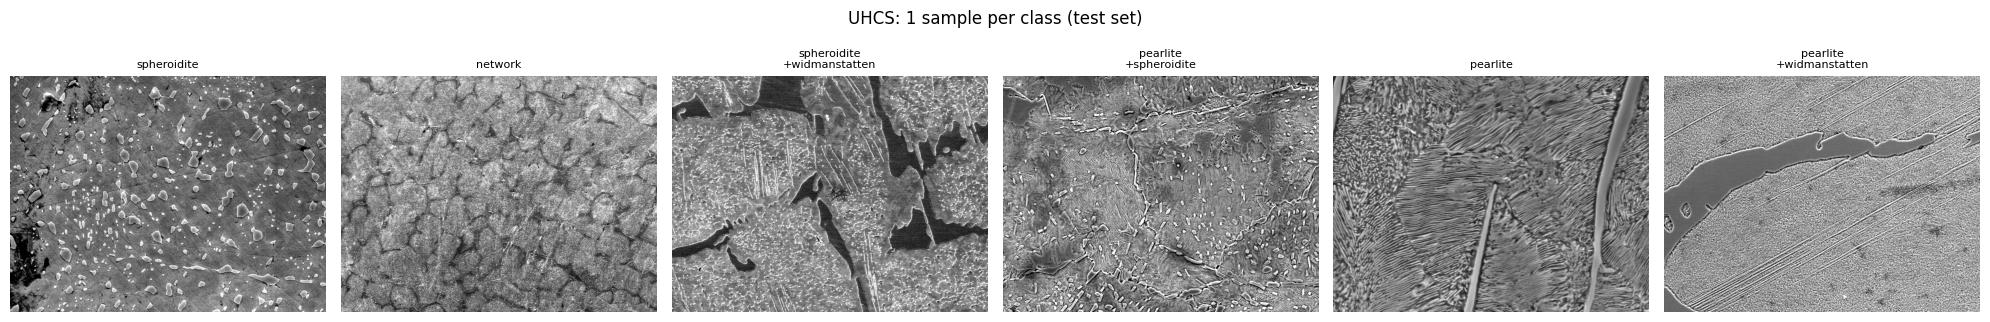

In [4]:
# Preview: 1 image per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 3.5))
for i, cls in enumerate(CLASSES):
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry:
        img = Image.open(entry['image']).convert('RGB')
        axes[i].imshow(img); axes[i].set_title(cls.replace('+','\n+'), fontsize=8); axes[i].axis('off')
        img.close()
plt.suptitle('UHCS: 1 sample per class (test set)', fontsize=12)
plt.tight_layout(); plt.show()

Reference image loaded: (1785, 1132)


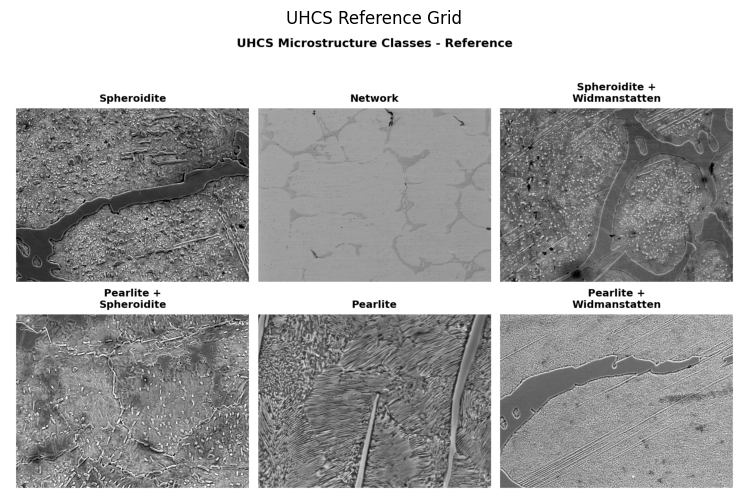

In [5]:
# Load reference image
ref_image = None
if os.path.exists(REF_IMAGE_PATH):
    ref_image = Image.open(REF_IMAGE_PATH).convert('RGB')
    print(f'Reference image loaded: {ref_image.size}')
    plt.figure(figsize=(10, 6))
    plt.imshow(ref_image); plt.title('UHCS Reference Grid'); plt.axis('off'); plt.show()
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found')

## Load Model

In [6]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map='auto',
    max_memory={0: '6GiB', 1: '15GiB'})
print('Model loaded.')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.24it/s]


Model loaded.


## Helpers

In [7]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"primary_microconstituent"\s*:\s*"([\w+]+)"', raw)
    if dm: return {'primary_microconstituent': dm.group(1)}
    # Fallback: match class names
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):  # longest first to match compound classes
        if cls in raw_lower: return {'primary_microconstituent': cls}
    return None

def infer(img_path, mode='zero-shot', ref_img=None, magnification='unknown'):
    image = Image.open(img_path).convert('RGB')
    if mode == 'few-shot' and ref_img is not None:
        msgs = [{'role':'user','content':[
            {'type':'image','image':ref_img},
            {'type':'text','text':make_prompt_fs_ref()},
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_fs_query(magnification)},
        ]}]
        images = [ref_img, image]
    else:
        msgs = [{'role':'user','content':[
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_zs(magnification)},
        ]}]
        images = [image]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=images, return_tensors='pt', padding=True).to(model.device)
    t = time.time()
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=80, temperature=0.1, do_sample=True)
    elapsed = time.time() - t
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    return out, elapsed

def run_benchmark(manifest, mode, ref_img=None, limit=None):
    data = manifest[:limit] if limit else manifest
    results=[]; correct=0; valid=0; tt=0
    for i, entry in enumerate(data):
        mag = entry.get('magnification', 'unknown')
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ref_img, magnification=mag)
        tt += elapsed
        parsed = parse_response(raw)
        gt = entry['class']
        ok = False
        if parsed:
            valid += 1
            pred = parsed.get('primary_microconstituent', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'magnification': mag,
            'predicted': parsed, 'raw': raw, 'correct': ok,
            'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        if (i+1) % 20 == 0:
            n = i+1
            print(f'  [{n}/{len(data)}] Acc: {correct}/{n} ({correct/n*100:.0f}%) | JSON: {valid}/{n}')
    return results, correct, valid, tt

print('Helpers ready.')

Helpers ready.


## Quick Test (1 per class)

In [8]:
quick = []
for cls in CLASSES:
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry: quick.append(entry)

for mode in ['zero-shot', 'few-shot']:
    print(f'\n{"="*55}')
    print(f'Quick test — {mode}')
    print(f'{"="*55}')
    ri = ref_image if mode == 'few-shot' else None
    for entry in quick:
        mag = entry.get('magnification', 'unknown')
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ri, magnification=mag)
        parsed = parse_response(raw)
        gt = entry['class']
        pred = parsed.get('primary_microconstituent', '?') if parsed else '?'
        ok = '✓' if pred == gt else '✗'
        print(f'  {gt:>28} → {pred:<28} {ok} ({elapsed:.1f}s)')


Quick test — zero-shot
                   spheroidite → spheroidite                  ✓ (3.3s)
                       network → network                      ✓ (2.7s)
     spheroidite+widmanstatten → spheroidite                  ✗ (3.1s)
          pearlite+spheroidite → network                      ✗ (2.7s)
                      pearlite → network                      ✗ (2.4s)
        pearlite+widmanstatten → network                      ✗ (2.4s)

Quick test — few-shot
                   spheroidite → spheroidite                  ✓ (3.6s)
                       network → network                      ✓ (3.3s)
     spheroidite+widmanstatten → pearlite+spheroidite         ✗ (3.8s)
          pearlite+spheroidite → pearlite+spheroidite         ✓ (3.7s)
                      pearlite → pearlite+spheroidite         ✗ (3.7s)
        pearlite+widmanstatten → pearlite+spheroidite         ✗ (3.7s)


## Full Benchmark — Zero-Shot

In [9]:
print('Running zero-shot...')
zs_results, zs_correct, zs_valid, zs_time = run_benchmark(manifest, 'zero-shot')
n = len(zs_results)
print(f'\nZero-shot: Acc={zs_correct}/{n} ({zs_correct/n*100:.1f}%) | JSON={zs_valid}/{n} | Time={zs_time/n:.1f}s/img')

Running zero-shot...
  [20/120] Acc: 17/20 (85%) | JSON: 20/20
  [40/120] Acc: 31/40 (78%) | JSON: 40/40
  [60/120] Acc: 40/60 (67%) | JSON: 60/60
  [80/120] Acc: 60/80 (75%) | JSON: 80/80
  [100/120] Acc: 73/100 (73%) | JSON: 100/100
  [120/120] Acc: 73/120 (61%) | JSON: 120/120

Zero-shot: Acc=73/120 (60.8%) | JSON=120/120 | Time=2.5s/img


## Full Benchmark — Few-Shot

In [10]:
print('Running few-shot...')
fs_results, fs_correct, fs_valid, fs_time = run_benchmark(manifest, 'few-shot', ref_img=ref_image)
n = len(fs_results)
print(f'\nFew-shot: Acc={fs_correct}/{n} ({fs_correct/n*100:.1f}%) | JSON={fs_valid}/{n} | Time={fs_time/n:.1f}s/img')

Running few-shot...
  [20/120] Acc: 11/20 (55%) | JSON: 20/20
  [40/120] Acc: 22/40 (55%) | JSON: 40/40
  [60/120] Acc: 30/60 (50%) | JSON: 60/60
  [80/120] Acc: 41/80 (51%) | JSON: 80/80
  [100/120] Acc: 46/100 (46%) | JSON: 100/100
  [120/120] Acc: 51/120 (42%) | JSON: 120/120

Few-shot: Acc=51/120 (42.5%) | JSON=120/120 | Time=3.6s/img


## Results

In [11]:
n = len(zs_results)
print(f'{"Method":<20} {"Accuracy":>10} {"JSON Valid":>12} {"Time/img":>10}')
print('=' * 54)
print(f'{"Qwen ZS":<20} {zs_correct/n*100:>9.1f}% {zs_valid/n*100:>11.0f}% {zs_time/n:>9.1f}s')
print(f'{"Qwen FS":<20} {fs_correct/n*100:>9.1f}% {fs_valid/n*100:>11.0f}% {fs_time/n:>9.1f}s')
print(f'{"Random chance":<20} {100/6:>9.1f}%')

# Per-class
print(f'\nPer-class accuracy:')
print(f'{"Class":<30} {"ZS":>8} {"FS":>8}')
print('-' * 48)
for cls in CLASSES:
    zs_cls = [r for r in zs_results if r['class'] == cls]
    fs_cls = [r for r in fs_results if r['class'] == cls]
    zs_c = sum(1 for r in zs_cls if r['correct'])
    fs_c = sum(1 for r in fs_cls if r['correct'])
    zs_pct = f'{zs_c}/{len(zs_cls)}' if zs_cls else 'N/A'
    fs_pct = f'{fs_c}/{len(fs_cls)}' if fs_cls else 'N/A'
    print(f'{cls:<30} {zs_pct:>8} {fs_pct:>8}')

Method                 Accuracy   JSON Valid   Time/img
Qwen ZS                   60.8%         100%       2.5s
Qwen FS                   42.5%         100%       3.6s
Random chance             16.7%

Per-class accuracy:
Class                                ZS       FS
------------------------------------------------
spheroidite                       54/74    38/74
network                           19/20     7/20
spheroidite+widmanstatten          0/15     2/15
pearlite+spheroidite                0/5      4/5
pearlite                            0/3      0/3
pearlite+widmanstatten              0/3      0/3


## Save Results

In [12]:
for label, results, correct, valid, tt in [
    ('zero-shot', zs_results, zs_correct, zs_valid, zs_time),
    ('few-shot', fs_results, fs_correct, fs_valid, fs_time),
]:
    n = len(results)
    with open(f'benchmark_results_{label}.json', 'w') as f:
        json.dump({'model': MODEL_ID, 'mode': label, 'dataset': 'UHCS',
            'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
            'json_validity_pct': round(valid/n*100, 1),
            'avg_inference_time_s': round(tt/n, 2),
            'results': results}, f, indent=2)
    print(f'Saved benchmark_results_{label}.json')

Saved benchmark_results_zero-shot.json
Saved benchmark_results_few-shot.json
